In [110]:
REPORT   = "cost-report/tpch100-v5"
BASELINE = "cost-report/tpch100-v5-orig"
LAST     = []

## Style và dữ liệu

In [111]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import cost_accuracy as ca            # chỉ dùng để đọc dữ liệu
%matplotlib inline

fm.fontManager.addfont("./fonts/LinLibertine_R.otf")
plt.rcParams['font.family'] = 'Linux Libertine O'
plt.rcParams['font.serif'] = ['Linux Libertine O']
FONT_SIZE = 13
plt.rcParams['font.size'] = FONT_SIZE
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['lines.linewidth'] = 0.8

plt.rcParams.update({
    "axes.grid": True, "legend.frameon": False,
    "axes.spines.top": True, "axes.spines.right": True,   # khung 4 cạnh (False = chỉ trục trái và dưới)
    "pdf.fonttype": 42, "ps.fonttype": 42,      # nhúng font TrueType vào PDF
    "savefig.dpi": 300, "savefig.bbox": "tight",
})

# màu và nhãn
SYS    = ["base", "s3", "nfs"]
LABEL  = {"base": "BLOOM-FaaS", "s3": "BLOOM-FaaS S3", "nfs": "BLOOM-FaaS FS"}
SHORT  = {"base": "BLOOM-FaaS", "s3": "BLOOM-FaaS S3", "nfs": "BLOOM-FaaS FS"}
COLOR  = {"base": "#2a78d6", "s3": "#eb6834", "nfs": "#1baf7a"}
METRIC = {"T": "Latency T", "C": "Cost C"}
plt.rcParams.update({                 # số mũ trục log (10¹) và ký hiệu toán cũng dùng Libertine thay vì DejaVu Sans
    "mathtext.fontset": "custom", "mathtext.rm": "Linux Libertine O",
    "mathtext.it": "Linux Libertine O", "mathtext.bf": "Linux Libertine O", "axes.unicode_minus": True,
})
neg = lambda s: s.replace("-", "\u2212")   # dấu trừ thật (−) cho các nhãn số tự định dạng
INK, INK2, GRID = "#000000", "#52514e", "#e4e3df"
plt.rcParams.update({"axes.edgecolor": INK2, "axes.labelcolor": INK, "xtick.color": INK2, "ytick.color": INK2,
                     "grid.color": GRID})
plt.rcParams.update({"text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black", "legend.labelcolor": "black"})  # chữ đen toàn bộ
DIVERGING = ["#184f95", "#6da7ec", "#f0efec", "#ef8f8e", "#b8302f"]   # xanh (model thấp) - xám - đỏ (model cao)

OUT = os.path.join(REPORT, "accuracy" + ("-last-" + "-".join(LAST) if LAST else ""), "paper")
os.makedirs(OUT, exist_ok=True)


DPI = 300                             # độ phân giải khi lưu PNG (PDF là vector, không ảnh hưởng)
COST_UNIT, COST_SCALE = "¢", 100      # đơn vị chi phí trên chart: ("¢", 100) cent, ("\\$", 1) dollar


def save(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(os.path.join(OUT, f"{name}.{ext}"), dpi=DPI)


# dữ liệu: một dòng / (query, system, metric) với meas, model, err (median), err_min, err_max, mape
pq   = ca.per_query(ca.load_runs(REPORT, LAST))
base = ca.per_query(ca.load_runs(BASELINE, LAST)) if BASELINE else None
QUERIES = sorted(pq["query"].unique(), key=ca.qnum)
mape = lambda df, m, s=None: df[(df.metric == m) & ((df.system == s) if s else True)]["mape"].mean()
print("saving to", OUT)
pq.head()

saving to cost-report/tpch100-v5/accuracy/paper


,query,system,metric,runs,meas,model,err,err_min,err_max,mape,decision_match
0,q2,base,C,15,0.004205,0.004780,13.677723,7.979212,15.069903,13.023879,NaN
1,q2,base,T,15,6.572694,7.018240,6.716170,-7.777452,8.580299,6.593292,NaN
2,q2,s3,C,15,0.001185,0.001546,30.468490,28.031598,33.115592,30.553952,15/15
3,q2,s3,T,15,3.901410,4.359981,11.868565,-5.448712,14.816372,11.715237,15/15
4,q2,nfs,C,15,0.000698,0.001055,51.054354,46.529992,53.695107,50.683163,15/15


## Hàm vẽ: sai số tuyệt đối theo query (trái) + trung bình 3 system (phải)


In [112]:
runs = ca.load_runs(REPORT, LAST)
ABS = (runs[runs.metric.isin(list(METRIC))] .groupby(["query", "system", "metric"])["abs_err_%"] .agg(mean="mean", lo="min", hi="max"))

def plot_abs_err(M, title=None, ylabel="Absolute prediction error (%)", figsize=(8, 3), ytop=None, name=None, legend_ncol=1):
    d = ABS.xs(M, level="metric")
    bw = 0.8 / len(SYS)
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=figsize, sharey=True, gridspec_kw={"width_ratios": [0.9, 0.1], "wspace": 0.03})

    for k, s in enumerate(SYS):
        qs = [q for q in QUERIES if (q, s) in d.index]
        xs = np.array([QUERIES.index(q) for q in qs]) + (k - (len(SYS) - 1) / 2) * bw
        v = d.loc[[(q, s) for q in qs]]
        ax.bar(xs, v["mean"], bw, color=COLOR[s], edgecolor="black", linewidth=0.6, label=LABEL[s],  yerr=[v["mean"] - v["lo"], v["hi"] - v["mean"]], error_kw={"elinewidth": 0.6, "capsize": 1.5, "capthick": 0.5, "ecolor": INK}, zorder=2)

    ax.set_xticks(range(len(QUERIES)), [q.upper() for q in QUERIES], rotation=45)
    ax.set_xlim(-0.5, len(QUERIES) - 0.5)
    ax.set_ylim(0, ytop or ABS.xs(M, level="metric")["hi"].max() * 1.22)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("TPC-H query")
    ax.legend(loc="upper right", ncol=legend_ncol, frameon=True, edgecolor="black", fancybox=False, framealpha=1, fontsize=FONT_SIZE - 2, borderpad=0.3, labelspacing=0.2, handlelength=1.0, handletextpad=0.4, columnspacing=0.8)

    if title:
        ax.set_title(title, loc="left", fontsize=FONT_SIZE)

    avg = [d.xs(s, level="system")["mean"].mean() for s in SYS]
    bars = ax2.bar(range(len(SYS)), avg, 0.7, color=[COLOR[s] for s in SYS], edgecolor="black", linewidth=0.6, zorder=2)

    for b, v in zip(bars, avg):
        ax2.annotate(f"{v:.1f}", (b.get_x() + b.get_width() / 2, v), xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", rotation=90, fontsize=FONT_SIZE - 2)

    ax2.set_xticks(range(len(SYS)), [])
    ax2.set_xlim(-0.7, len(SYS) - 0.3)
    ax2.set_xlabel("Average")
    ax2.tick_params(axis="y", left=False)
    ax2.set_ylabel("MAPE (%)")
    ax2.yaxis.set_label_position("right")

    for a in (ax, ax2):
        a.grid(axis="x", visible=False)
        a.grid(axis="y", alpha=0.6, linestyle="--")
        a.set_axisbelow(True)
        for sp in a.spines.values():
            sp.set_color("black"); sp.set_linewidth(0.8)
        a.tick_params(width=0.8, length=3)

    for s, v in zip(SYS, avg):
        print(f"- {LABEL[s]}: MAPE {M} = {v:.2f}%")
    if name:
        save(fig, name)
    plt.show()


## B. Sai số tuyệt đối (%) theo query: Latency T

- BLOOM-FaaS: MAPE T = 17.96%
- BLOOM-FaaS S3: MAPE T = 16.49%
- BLOOM-FaaS FS: MAPE T = 18.50%


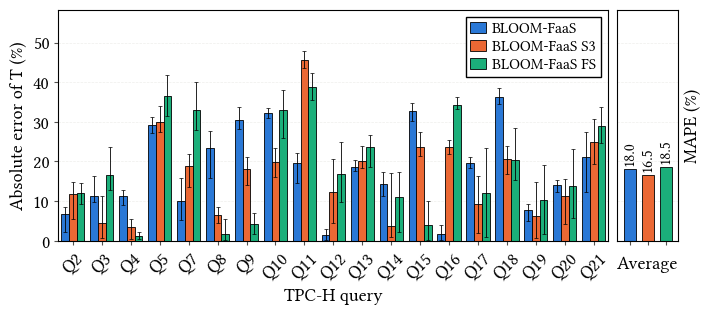

In [113]:
plot_abs_err(
    "T",
    title=None, # "Latency model (T): absolute prediction error per query, TPC-H SF100",   # None để bỏ
    ylabel="Absolute error of T (%)",
    name="cost-accuracy-err-T",
)

## C. Sai số tuyệt đối (%) theo query: Cost C

- BLOOM-FaaS: MAPE C = 12.46%
- BLOOM-FaaS S3: MAPE C = 13.42%
- BLOOM-FaaS FS: MAPE C = 20.40%


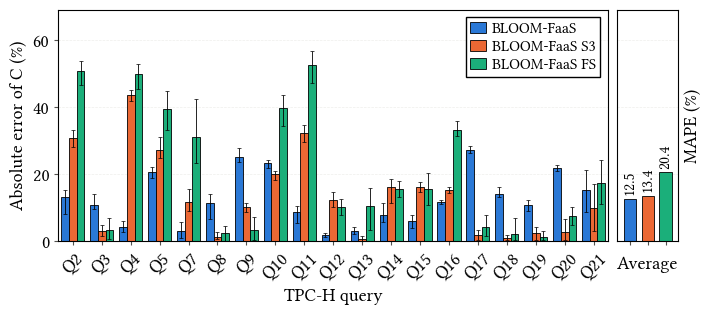

In [114]:
plot_abs_err(
    "C",
    title=None, #"Cost model (C): absolute prediction error per query, TPC-H SF100",      # None để bỏ
    ylabel="Absolute error of C (%)",
    name="cost-accuracy-err-C",
)